# Natural Language Processing - Attention

3Blue1Brown has recently dropped a fantasically visual explanation of attention. Be sure to check out the below:
    
https://www.youtube.com/watch?v=eMlx5fFNoYc&t=1s

# Attention Architectures

Although attention is implemented differently in neural networks than it is biologically or psychologically, in both contexts it can be defined as the ability to highlight and use the salient parts of the information at hand.

<img src="https://www.tensorflow.org/images/tutorials/transformer/encoder_self_attention_distribution.png">
source: <a href="https://www.tensorflow.org/text/tutorials/transformer">https://www.tensorflow.org/text/tutorials/transformer</a>

----

<i>"We can think of an attention-based system as having three components:</i>

1. <i>A process that reads raw data (such as source words in a source sentence), and converts them into distributed representations, with one feature vector associated with each word position.</i>

2. <i>A list of feature vectors storing the output of the reader. This can be understood as a "memory" containing a sequence of facts, which can be retrieved later, not necessarily in the same order, without having to visit them all.</i>

3. <i>A process that "exploits" the content of the memory to sequentially perform a task, at each time step having the ability to put attention on the content of one memory element (or a few, with a different weight)."</i>

- Deep Learning (2016)

----

We'll get to transformers and self-attention, but first discuss attention in general.

The attention mechanism was introduced in the context of an RNN encoder-decoder framework. The encoder is fed an input sequence of words, and outputs a vector for every element in the sequence. A list of these vectors, together with the decoder's previous hidden states, are exploited by the attention mechanism to dynamicallly highlight which of the input information will be used to generate the output. The encoded vectors and previous state of the decoder are used to generate unnormalized score values that indicate how well the elements of the input sequence algorithm align with the current output. The scores are then normalized by a softmax function to generate the weights. Finally, the encoded vectors are scaled by the computed weights to generate a context vector, which is fed into the decoder to generate a translated output.

In a process that does not incorporate an attention mechanism, an encoder would generate a fixed-length vector irrespective of the input's length or complexity. The decoder would only have access to the limited information encoded.

The following diagram shows an overview of the model. The encoder is on the left, decoder on the right (in both). At each time-step, the decoder's output is combined with the encoder's output to predict the next word.

<img width=500 src="https://www.tensorflow.org/images/seq2seq/attention_mechanism.jpg"/>

Source: https://www.tensorflow.org/text/tutorials/nmt_with_attention

The encoder does the following:
1. Take in a list of token IDs
2. Look up an embedding vector for each token
3. Process the embeddings into a new sequence
4. Return the processed sequence to be passed to the attention head

The attention layer computes a vector from the entire context sequence and adds that to the decoder's output. The weights are calculated from the combination of context and query vectors.

The decoder generates predictions for the next token at each location in the target sequence by:
1. Looking up embeddings for each token in the target sequence
2. Using an RNN to process the target sequence and keep track of what has been generated so far
3. Using an RNN output as the 'query' to the attention layer, when attending to the encoder's output
4. At each location in the output, predicting the next token

## The Bahdanau Architecture

--- 

<i>"Bahdanau et al. (2015) employed the use of RNNs for both encoding and decoding tasks. The encoder employs a bidirectional RNN to generate a series of annotations that contain a summary of preceding and succeeding words that can be mapped to a context vector through a weighted sum. The decoder then generates an output based on these annotations and the hidden states of another RNN"</i>
- Building Transformer Models with Attention (2022)

---

The Bahdanau attention algorithm performs the following:

<h5><u>Step 1:</u></h5>

- The RNN encoder generates a set of annotations $\mathbf{h}_i$ from the input sentence.

<h5><u>Step 2:</u></h5>

- The decoder takes each annotation and feeds it to an alignment model $a(\cdot)$ together with the previous hidden decoder state $\mathbf{s}_{t-1}$, generating an attention score, $e_{t,i} = a(\mathbf{s}_{t-1}, \mathbf{h}_i)$. This can be implemented by either applying a weight matrix $\mathbf{W}$ over the concatenated vectors $\mathbf{s}_{t-1}$ and $\mathbf{h}_i$, or applying the weight matrices $\mathbf{W}_1$ and $\mathbf{W}_2$ to $\mathbf{s}_{t-1}$ and $\mathbf{h}_i$ separately.

<h5><u>Step 3:</u></h5>

- A softmax function is applied to the attention scores, normalizing them into weight values $\alpha_{t,i}$ ranging between $0$ and $1$. The resulting weights can be considered probability values. Each weight reflects how important $\mathbf{h}_i$ and $\mathbf{s}_{t-1}$ are in generating the next state $\mathbf{s}_t$ and the next output $y_t$.

<h5><u>Step 4:</u></h5>

- Together with the previously computed annotations, the weights are used to generate a context vector, a weighted sum of the annotations and normalized alignment scores, $\mathbf{c}_t = \sum_{i=1}^T \alpha_{t,i} \mathbf{h}_i$

<h5><u>Step 5:</u></h5>

- The context vector is fed to the decoder together with the previous hidden decoder state and the previous output to compute the final output $y_t$.

<h5><u>Step 6:</u></h5>

- Steps 2-5 repeat until end of sequence.


## The Luong Architecture

Luong et al. (2015) introduced the idea of global vs. local attention. A global attention model is one that, when deriving the context vector, considers all the hidden states of the encoder. The global context vector is based on a weighted average of all the words in the source sequence.

----

<i>"In this work, we design, with simplicity and effectiveness in mind, two novel types of attention-based models: a global approach which always attends to all source words and a local one that only looks at a subset of words at a time."</i>
- Effective Approaches to Attention-Based Neural Translation (2015)

---- 

The global attention model resembles the Bahdanau et al. model in attending to all source words but aims to simplify it architecturally. The local attention model is inspired by the hard and soft attentional models of Xu et al., and attend to only a few of the source positions.

The Luong algorithm performs the following operations:

<h5><u>Step 1:</u></h5>

- The encoder generates a set of annotations $H$ from the input sentence.

<h5><u>Step 2:</u></h5>

- The current decoder hidden state is computed as $\mathbf{s}_t = RNN_{decoder} (\mathbf{s}_{t-1}, y_{t-1})$. $\mathbf{s}_{t-1}$ denotes the previous hidden decoder state and $y_{t-1}$ the previous decoder output.

<h5><u>Step 3:</u></h5>

- An alignment model $a()$, uses the annotations and current decoder hidden state to compute the alignment scores, 
$e_{t,i} = a (\mathbf{s}_t, \mathbf{h}_i)$.


<h5><u>Step 4:</u></h5>

- A softmax function is applied to the alignment scores, normalizing them.

<h5><u>Step 5:</u></h5>

- Together with the previously computed annotations, those weights are used to generate a context vector through a weighted sum of the annotations, $\mathbf{s}_t = \sum_{i=1}^T ~\alpha_{t,i} \mathbf{h}_i$

<h5><u>Step 6:</u></h5>

- An attentional hidden state is computed based on a weighted concatenation of the context vector and the current decoder hidden state, $\tilde{\mathbf{s}}_t = tanh( \mathbf{w}_c [\mathbf{c}_t; \mathbf{s}_t] )$

<h5><u>Step 7:</u></h5>

- The decoder produces a final output by feeding it a weighted attentional hidden state, $y_t = softmax(\mathbf{W}_y \tilde{\mathbf{s}}_t)$

<h5><u>Step 8</u></h5>

- Steps 2-7 are repeated until the end of the sequence

</br>
The idea of a global attention model is to consider all the hidden states of the encoder when deriving the context vector $\mathbf{c}_t$. The local attention model of Luong et al. generates a context vector by computing a weighted average over the set of annotations $\mathbf{h}_i$ within a window centered over an aligned position $p_t$.
<p></p>
$window = [p_t - D, p_t + D]$

<p></p>
A value for $D$ is selected empirically, and Luong et al. consider two approaches in computing value for $p_t$.
1. Monotonic alignment: where the source and target sentences are assigned to be monotonically aligned, and hence, $p_t = t$.
2. Predictive alignment: a prediction of the aligned position is based upon trainable model parameters $\mathbf{W}_p$ and $\mathbf{v}_p$ and the source sentence length $s$.

$p_t = s \cdot \sigma(\mathbf{v}_p^T ~tanh(\mathbf{W}_p, \mathbf{s}_t))$

Most notably, the computation of alignment scores $e_t$ in the Luong global attentional model depends on the current decoder hidden state rather than on the previous hidden state $\mathbf{s}_{t-1}$ in the Bahdanau attention.

# Encoding General Attention

If working with hard attention, we can think of vector $\mathbf{s}_{t-1}$ as a query executed against a database of key-value pairs, where the keys are vectors and the hidden states $\mathbf{h}_i$ are the values. The keys $\mathbf{K}$ and values $\mathbf{V}$ of Luong and Bahdanau attention are the same vector.

---- 
<i>"We can think of the vector $\mathbf{s}_{t-1}$ as a query executed against a database of key-value pairs, where the keys are vectors and the hidden state $\mathbf{h}_i$ are the values."</i>
- Advanced Deep Learning in Python (2019)

---- 

<i>"Queries, keys, and values are the fundamental concepts of the attention mechanism in transformer models. It compares the queries with the keys to generate a similarity score, which is then used to weigh the values. The weighted values are then summed to generate the output of the attention mechanism."</i>
- Attention Mechanisms in Transformers (2023)

----

<i>"The query is the information you are trying to match to. The key and values are the stored information. For example, using the following simplified database of keys and values:</i>

<code>d = {'panther': 1, 'bear': 10, 'dog': 30}</code>

<i>The query 'wolf' may be expressed as something like the following:</i>

<code>d['wolf'] = 0.2 times d['panther'] + 0.7 \times d['bear'] + 0.1 \times d['dog']"</code>
- A Complete Guide to Write Your Own Transformers (2023)

----

 <table>
<tr>
  <th colspan=1>The base attention layer</th>
</tr>
<tr>
  <td>
   <img width=430 src="https://www.tensorflow.org/images/tutorials/transformer/BaseAttention-new.png"/>
  </td>
</tr>
</table>

Source: https://www.tensorflow.org/text/tutorials/transformer

</br>
With soft attention, where all values participate, we can think in the same query/key/value terms, but instead of a single value, the query results are all values with different weights.

<h3>$\alpha_{\mathbf{q}, \mathbf{k}_i} = \frac{ exp(e_{\mathbf{q},\mathbf{k}_i}) }{ \sum_j exp(e_{\mathbf{q}, \mathbf{k}_j} }$</h3>

<h4>$Attention(\mathbf{q}, \mathbf{K}, \mathbf{V}) = \sum_i \alpha_{\mathbf{q}, \mathbf{k}_i, \mathbf{v}_k}$</h4>

The algorithm is as follows:
</br>

<h5><u>Step 1:</u></h5>

- Each query vector $\mathbf{q} = \mathbf{s}_{t-1}$ is matched against a database of keys to compute a score value, as the dot product of the specific query under consideration with each key vector $\mathbf{k}$.
- $e_{q,k_i} = \mathbf{q} \cdot \mathbf{k}_i$

In [1]:
# code adapted from Building Transformer Models wtih Attention, Stefania Cristina and Mehreen Saeed
# https://machinelearningmastery.com/transformer-models-with-attention/

from numpy import array
from numpy import random
from numpy import dot
from scipy.special import softmax

word_1 = array([1, 0, 0])
word_2 = array([0, 1, 0])
word_3 = array([1, 1, 0])
word_4 = array([0, 0, 1])

words = array([word_1, word_2, word_3, word_4])

W_Q = random.randint(3, size=(3, 3))
W_K = random.randint(3, size=(3, 3))
W_V = random.randint(3, size=(3, 3))

Q = words @ W_Q
K = words @ W_K
V = words @ W_V

Q, K, V

(array([[2, 2, 2],
        [0, 2, 0],
        [2, 4, 2],
        [1, 1, 0]]),
 array([[1, 2, 0],
        [0, 2, 0],
        [1, 4, 0],
        [0, 1, 2]]),
 array([[0, 0, 0],
        [0, 2, 0],
        [0, 2, 0],
        [2, 0, 1]]))

In [2]:
scores = Q @ K.transpose()
scores

array([[ 6,  4, 10,  6],
       [ 4,  4,  8,  2],
       [10,  8, 18,  8],
       [ 3,  2,  5,  1]])

<h5><u>Step 2:</u></h5>

- The scores are passed through a softmax operation to generate the weights, $\alpha_{q,k_i} = softmax(e_{q,k_i})$.

In [3]:
weights = softmax(scores / K.shape[1] ** 0.5, axis=1)
weights

array([[0.08075232, 0.02544925, 0.8130461 , 0.08075232],
       [0.08075232, 0.08075232, 0.8130461 , 0.02544925],
       [0.00970847, 0.00305964, 0.98417224, 0.00305964],
       [0.19803514, 0.11117374, 0.62837997, 0.06241115]])

<h5><u>Step 3:</u></h5>

- The generalized attention is then computed by a weighted sum of the value vectors $\mathbf{v}_{\mathbf{k}_i}$, where each value vector is paired with a corresponding key.

$attention(\mathbf{q}, \mathbf{K}, \mathbf{V}) = \sum_i \alpha_{\mathbf{q}, \mathbf{k}_i} \mathbf{v}_{\mathbf{k}_i}$

In [4]:
attention = weights @ V
attention

array([[0.16150465, 1.6769907 , 0.08075232],
       [0.0508985 , 1.78759686, 0.02544925],
       [0.00611929, 1.97446377, 0.00305964],
       [0.1248223 , 1.47910742, 0.06241115]])

# The Transformer

<img width=400 src="https://www.tensorflow.org/images/tutorials/transformer/transformer.png"/>

Source: https://www.tensorflow.org/text/tutorials/transformer

Vaswani et al. (2017) proposed the transformer architecture, with the seminal paper "Attention is All You Need". It dispenses with recurrence and convolutions, and implements a self-attention mechanism. The sequential nature of RNNs makes them difficult to take advantage of parallel processing, whereas the Transformer only performs a small, constant number of steps.

----

<i>"The transformer is the first transduction model relying on self-attention to compute representations of its input and output without using sequence-aligned RNNs or convolutions."</i>
- Attention Is All You Need (2017)

----

<i>"The self-attention mechanism still relies on the use of queries, keys, and values, generated by multiplying the encoder's representation of the input sequence with different weight matrices. It uses dot product (multiplicative) attention, where each query is matched against a database of keys by a dot product operation in the prcoess of generating the attention weights. These weights are then multiplied by the values to generate a final attention vector."</i>
- Building Transformer Models with Attention (2022)

----

The main components used by the transformer attention are the following $\mathbf{q}$ and $\mathbf{k}$ denoting vectors of dimension $d_k$, containing the queries and keys $\mathbf{v}$ denoting a vector of dimension $d$, containing the values $\mathbf{Q}$, $\mathbf{K}$, and $\mathbf{v}$, denoting matrices packing together sets of queries, keys, and values $\mathbf{W}^Q$, $\mathbf{W}^k$, and $\mathbf{W}^v$, denoting projection matrices that are used in generating different subspace representations of the query, key, and value matrices $\mathbf{W}^O$ denoting a projection matrix for the multi-head output.

## Scaled Dot-Product Attention

Vaswani et al. propose scaled dot-product attention and build on it to propose multi-head attention. Within the context of neural machine translation, the query, keys, and values that are used as inputs to these attention mechanicsms are different projections of the same input sentence.

Scaled dot-product attention first computes a dot product for each query $\mathbf{q}$ with all of the keys $\mathbf{k}$. It divides each result by $\sqrt{d_k}$, where $d_k$ is the dimension of the vectors $\mathbf{q}$ and $\mathbf{k}$) and proceeds to apply a softmax function. In doing so, it obtains the weights that are used to scale the values $\mathbf{v}$.

$attention(Q,K,V) = softmax \left( \frac{QK^T}{\sqrt{d_k}} \right) V$

The scaling helps to prevent the vanishing gradient effect, in the wake of the softmax function.

The procedure for calculating scaled dot-product attention is:

<h5><u>Step 1:</u></h5>

- Compute the alignment scores by multiplying the set of queries packed in matrix $\mathbf{Q}$ with the keys in the matrix $\mathbf{K}$.

In [5]:
# code adapted from Building Transformer Models wtih Attention, Stefania Cristina and Mehreen Saeed
# https://machinelearningmastery.com/transformer-models-with-attention/

from numpy import random, float64
from tensorflow import math, matmul, reshape, shape, transpose, cast
from keras.layers import Dense, Layer
from keras.activations import softmax

input_seq_length = 5  # Maximum length of the input sequence
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
batch_size = 64  # Batch size from the training process

queries = random.random((batch_size, input_seq_length, d_k))
keys = random.random((batch_size, input_seq_length, d_k))
values = random.random((batch_size, input_seq_length, d_v))

print(queries.shape)
print(keys.shape)
print(values.shape)

(64, 5, 64)
(64, 5, 64)
(64, 5, 64)


In [6]:
scores = matmul(queries, keys, transpose_b=True)
print(scores.shape)

(64, 5, 5)


<h5><u>Step 2:</u></h5>

Scale each of the alignment scores by $\frac{1}{\sqrt{d_k}}$.

In [7]:
scores = scores / math.sqrt(cast(d_k, float64))
scores[0]

<tf.Tensor: shape=(5, 5), dtype=float64, numpy=
array([[1.62918301, 2.17162414, 2.11223601, 1.93304342, 2.17120586],
       [1.84170163, 1.90522185, 2.08216722, 2.0674266 , 1.92596824],
       [1.8106173 , 1.84582539, 2.0680748 , 2.0036568 , 1.89648599],
       [1.87531427, 1.98204992, 2.18716131, 2.0586965 , 2.05039605],
       [1.70133248, 1.82462848, 1.9449504 , 2.05362512, 2.0696505 ]])>

<h5><u>Step 3:</u></h5>

Follow the scaling process by applying a softmax function in order to obtain a set of weights.
$softmax \left( \frac{\mathbf{Q} \mathbf{K}^T}{\sqrt{d_k}} \right)$

In [8]:
weights = softmax(scores)
print(weights.shape)

(64, 5, 5)


<h5><u>Step 5:</u></h5>

Finally, apply the resulting weight to the values in matrix $\mathbf{v}$, of size $n \times d_v$.

In [9]:
attention = weights @ values

## Multi-Head Attention

Vaswani et al. propose a multi-head attention mechanism, which linearly projects the queries, keys, and values h times, using a different projection each time. The single attention mechanism is then applied to each of these h projections in parallel to produce h outputs, which are concatenated and projected again to produce a final output. This allows the attention function to extract information from different representation subspaces, which would be impossible with a single attention head.

<img src="https://www.tensorflow.org/images/tutorials/transformer/attention_map_portuguese.png">

Source: https://www.tensorflow.org/text/tutorials/transformer

$multihead(\mathbf{q}, \mathbf{K}, \mathbf{V}) = concat(head_1, \ldots, head_h) \mathbf{W}^O$

Each $head_i$implements a single attention function characterized by its own learned projection matrices

$head_i = attention(\mathbf{Q} \mathbf{W}_i^Q, \mathbf{K} \mathbf{W}_i^K, \mathbf{V} \mathbf{W}_i^V)$

The procedure for calculating multi-head attention is:

<h5><u>Step 1:</u></h5>

- Compute the linearly projected versions of the queries, keys, and values through multiplication with the respective weight matrices.

    $\mathbf{W}_i^Q, \mathbf{W}_i^k, \mathbf{W}_i^V$, one for each head.

<h5><u>Step 2:</u></h5> 

Apply the single attention function for each head by:

1. Multiplying the queries and keys matrices

2. Applying the scaling and softmax operations

3. Weighting the values matrix to generate an output for each head

Below, we start by importing necessary libraries:

In [10]:
# code adapted from Building Transformer Models wtih Attention, Stefania Cristina and Mehreen Saeed
# https://machinelearningmastery.com/transformer-models-with-attention/

from numpy import random, float64
from tensorflow import math, matmul, reshape, shape, transpose, cast
from keras.layers import Dense, Layer
from keras.activations import softmax

Then set some necessary variables, such as the dimensions of the data.

In [11]:
input_seq_length = 5  # Maximum length of the input sequence
heads = 8  # Number of self-attention heads
d_k = 64  # Dimensionality of the linearly projected queries and keys
d_v = 64  # Dimensionality of the linearly projected values
mask = 512  # Dimensionality of the model sub-layers' outputs
batch_size = 64  # Batch size from the training process

Then generate some random data.

In [12]:
queries = random.random((batch_size, input_seq_length, d_k))
keys = random.random((batch_size, input_seq_length, d_k))
values = random.random((batch_size, input_seq_length, d_v))

print(queries.shape)
print(keys.shape)
print(values.shape)

(64, 5, 64)
(64, 5, 64)
(64, 5, 64)


Then create attention layers which inherit from the Layer class of Keras.

In [13]:
W_q = Dense(d_k)   # Learned projection matrix for the queries
W_k = Dense(d_k)   # Learned projection matrix for the keys
W_v = Dense(d_v)   # Learned projection matrix for the values

The linearly projected queries, keys, and values will be rearranged into (batch size, number of heads, sequence length, depth), by first reshaping them into (batch size, sequence length, number of heads, depth) and then transposing the second and third dimensions.

In [14]:
def reshape_tensor(x, heads, flag):
    if flag:
        x = reshape(x, shape=(shape(x)[0], shape(x)[1], heads, -1))
        x = transpose(x, perm=(0, 2, 1, 3))
    else:
        x = transpose(x, perm=(0, 2, 1, 3))
        x = reshape(x, shape=(shape(x)[0], shape(x)[1], self.d_k))
    return x

In [15]:
q_reshaped = reshape_tensor(W_q(queries), heads, True)
k_reshaped = reshape_tensor(W_k(keys), heads, True)
v_reshaped = reshape_tensor(W_v(values), heads, True)

print(q_reshaped.shape)
print(k_reshaped.shape)
print(v_reshaped.shape)

(64, 8, 5, 8)
(64, 8, 5, 8)
(64, 8, 5, 8)


The scores are created by multiplying the queries with the keys, and are then scaled by $d_k$.

In [16]:
scores = matmul(queries, keys, transpose_b=True) / math.sqrt(cast(d_k, float64))

The mask is then applied and the scores put through a softmax fuction to obtain the weights.

In [17]:
scores += -1e9 * mask
weights = softmax(scores)

In [18]:
print(scores.shape)
print(weights.shape)
print(values.shape)

(64, 5, 5)
(64, 5, 5)
(64, 5, 64)


Finally, attention is calculated as the product of weights and values.

In [19]:
attention = weights @ values

The training process is then used to backpropagate error and optimize the weights.

## Positional Encoding

The model needs to understand not just the words but also their positions in a sentence. Positional encoding describes the location of an entity in a sequence, so that each position is assigned a unique representation. Each position (index) is mapped to a vector, so the output of the positional encoding layer is a matrix. 

For an input sequence of length L, we encode the $k^{th}$object as:

<h4>$p(k, 2i) = sin \left( \frac{k}{n^{2i ~/ ~d}} \right)$</h4>

<h4>$p(j, 2i+1) = cos \left( \frac{k}{n^{2i ~/ ~d}} \right)$</h4>

- $k$ is the position of an object in the input sequence, $0 \le k \lt L/2$
- $d$ is the dimension of the output embedding space
- $p(k,j)$ is the position function for mapping a position k in the input sequence to index $(k,j)$ of the positional matrix
- $n$ is a user-defined scalar, set to $10000$ in the "Attention is All You Need" paper
- $i$ is used for mapping to column indices $0 \le i \lt d/2$, where a single value of $i$ maps to both sine and cosine functions

One advantage of this scheme for positional encoding is values normalized to being within the range -1 to 1. 

In [20]:
# code adapted from Building Transformer Models wtih Attention, Stefania Cristina and Mehreen Saeed
# https://machinelearningmastery.com/transformer-models-with-attention/

import numpy as np
import matplotlib.pyplot as plt

def getPositionEncoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return P

P = getPositionEncoding(seq_len=4, d=4, n=100)
print(P)

[[ 0.          1.          0.          1.        ]
 [ 0.84147098  0.54030231  0.09983342  0.99500417]
 [ 0.90929743 -0.41614684  0.19866933  0.98006658]
 [ 0.14112001 -0.9899925   0.29552021  0.95533649]]


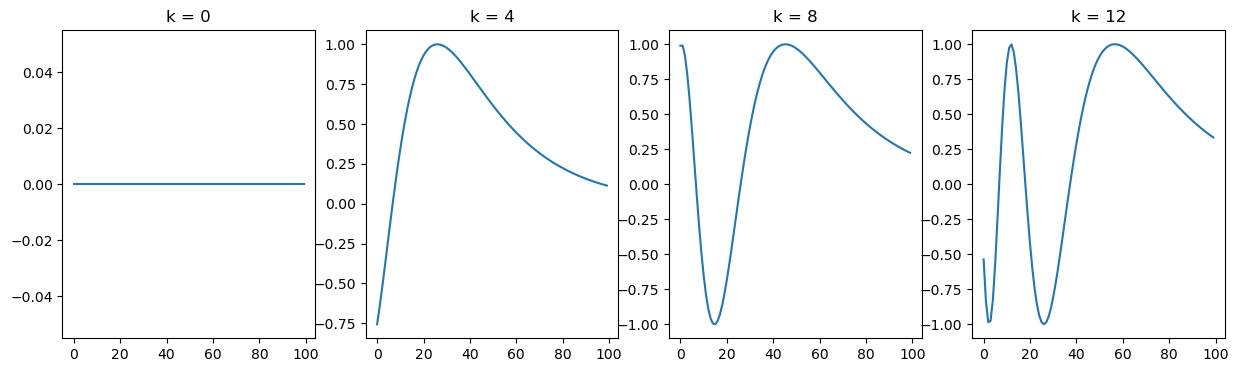

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plotSinusoid(k, d=512, n=10000):
    x = np.arange(0, 100, 1)
    denominator = np.power(n, 2*x/d)
    y = np.sin(k/denominator)
    plt.plot(x, y)
    plt.title('k = ' + str(k))

fig = plt.figure(figsize=(15, 4))
for i in range(4):
    plt.subplot(141 + i)
    plotSinusoid(i*4)
plt.show()

It's a little abstract, but such is good math.

## Summarizing the Transformer

The transformer has an encoder-decoder structure, but does not rely on recurrence. The number of sequential operations required by a recurrent layer is based on sequence length, whereas this number remains constant for a self-attention layer. Instead of recurrence, positional encoding vectors are used to inject positional information. The encoder maps an input sequence to a sequence of continuous representations, and the decoder receives the output of the encoder together with the decoder output of the previous time step in order to generate an output sequence.

The first sublayer implements multi-head self-attention. The second sublayer is a fully connected feedforward network (FFN) consisting of two linear transformations with a ReLU function between them.

The six layers of the encoder encode the same linear transformations to all the words in the input sequence, but each layer employs different weights and biases to do so. Following each sublayer is a normalization layer.

The decoder also has six layers, each of which are composed of 3 sublayers.

- <u>Sublayer 1</u> receives the previous output of the decoder, augments it with positional information, and implements multi-head self-attention over it. The decoder only attends to preceding words, so in the multi-head attention mechanism, this is achieved by putting a mask over the values produced by the scaled multiplication of matrices $\mathbf{Q}$ and $\mathbf{K}$.

- <u>Sublayer 2</u> implements a multi-head self-attention mechanism. On the decoder side, this mechanism receives the queries from the previous decode sublayer and the keys and values from the output of the encoder.

- <u>Sublayer 3</u> implements a fully connected FFN.

The first 3 layers are succeeded by a normalization layer. Positional encodings are added to the input embeddings of the decoder in the same manner as used for the decoder.



At this point you may be wanting to develop an entire transformer. A good resource for this is the Tensorflow Tutorial "Neural machine translation with a Transformer and Keras".

https://www.tensorflow.org/text/tutorials/transformer

# References

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press. 
https://www.deeplearningbook.org/

- Cristina, S., & Saeed, M. (2022). Building Transformer Models with Attention (A. Tam, Ed.) (1st ed.). MachineLearningMastery. https://machinelearningmastery.com/transformer-models-with-attention/

- Ashish Vaswani et al. “Attention Is All You Need”. In: Proc. 31st Conference on Neural
Information Processing Systems (NIPS 2017). 2017. https://arxiv.org/pdf/1706.03762.pdf

- Dzmitry Bahdanau, Kyunghyun Cho, and Yoshua Bengio. “Neural Machine Translation by
Jointly Learning to Align and Translate”. In: Proc. 3rd International Conference on
Learning Representations (ICLR 2015). May 2015. http://arxiv.org/abs/1409.0473

- Minh-Thang Luong, Hieu Pham, and Christopher D. Manning. “Effective Approaches to
Attention-based Neural Machine Translation”. In: Proc. EMNLP. Sept. 2015. DOI: 10.18653/v1/D15-1166. https://arxiv.org/abs/1508.04025

- Ivan Vasilev. Advanced Deep Learning with Python. Packt Publishing, 2019. https://www.amazon.com/dp/178995617X

- Shi, E. S. (2023). Attention Mechanisms in Transformers. Medium. https://medium.com/artificial-corner/attention-mechanisms-in-transformers-29c1768f83f3

- Etienne, B. (2023). A Complete Guide to Write your own Transformers. Towards Data Science. https://towardsdatascience.com/a-complete-guide-to-write-your-own-transformers-29e23f371ddd

- (n.d.). Neural machine translation with a Transformer and Keras. Tensorflow Tutorials. https://www.tensorflow.org/text/tutorials/transformer

- (n.d.). Neural machine translation with attention. Tensorflow Tutorials. https://www.tensorflow.org/text/tutorials/nmt_with_attention